# Pre-ANALYSIS

## Range distributions

/scratch/petgfn/Robert/PRcomp/analysis.py:366: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)
/scratch/petgfn/Robert/PRcomp/analysis.py:207: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


Size of annihilations sample:
     Positron 300keV                         	   1000000
     Electron 300keV                         	   1000000
Number of annihilation point coords:
     Positron 300keV                         	   1000000
     Electron 300keV                         	   1000000
Average radial distance traveled simulated:
     Positron 300keV                         	      0.59 mm
     Electron 300keV                         	      0.59 mm
Cummulative distances:
     Positron 300keV                         	50% @ 0.60mm	90% @ 0.76mm	99.9% @ 0.92mm
     Electron 300keV                         	50% @ 0.60mm	90% @ 0.76mm	99.9% @ 0.92mm
Maximum distances:
     Positron 300keV			1.02 mm
     Electron 300keV			1.05 mm


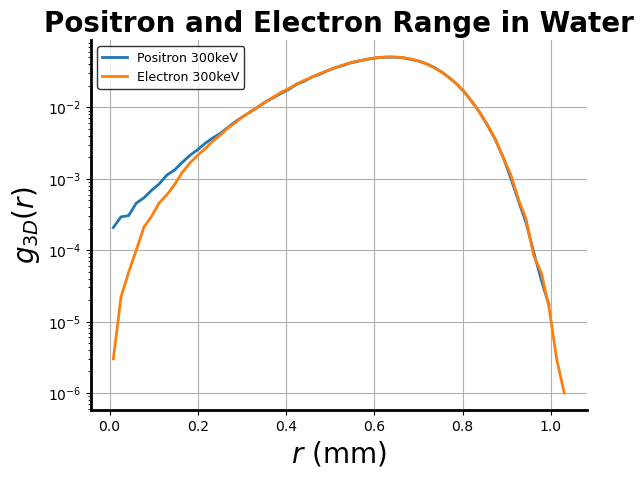

In [1]:
import analysis
results = analysis.GetResults()
ener = 300
results.load(f'Positron {ener}keV', f'RESULTS/PRofE/Water/PenEasy2024_xyz/e+/{ener}keV-range.dat', [201]*3, [1e-3]*3)
results.load(f'Electron {ener}keV', f'RESULTS/PRofE/Water/PenEasy2024_xyz/e-/{ener}keV-range.dat', [201]*3, [1e-3]*3)

# results.plot_aPSF3D(sin=False)
results.plot_g3D(title=f'Positron and Electron Range in Water')
results.data_analysis()
print("Maximum distances:")
for label, result in results.active_results.items():
    print(f"{label:>20s}\t\t\t{result.rmax*10:.2f} mm")

## Sources of energy loss

----------Ele


100%|##########| 48/48 [00:36<00:00,  1.33it/s]


----------Pos


100%|##########| 48/48 [00:36<00:00,  1.32it/s]


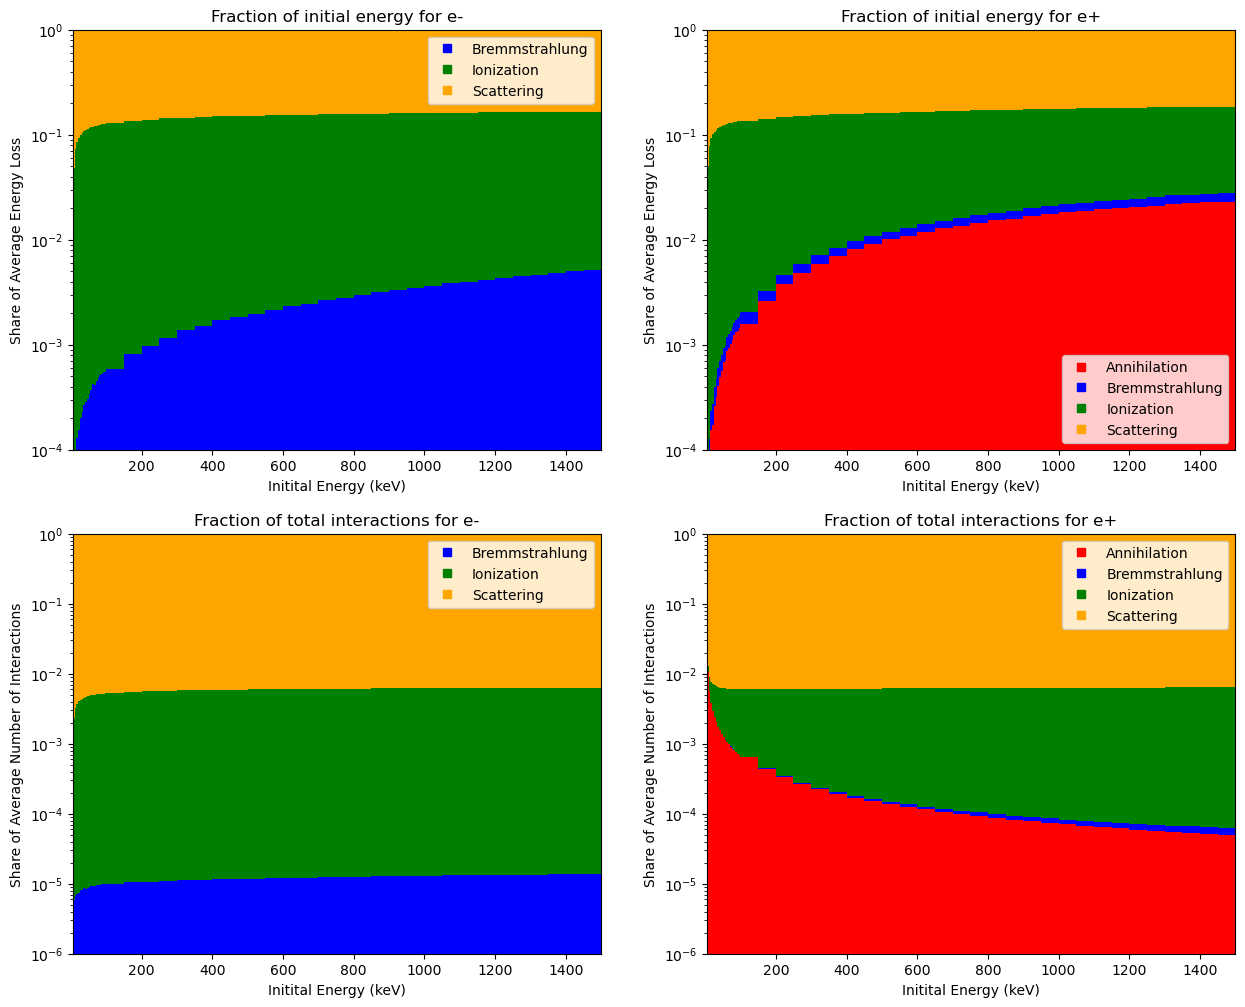

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fitPRd
from tqdm import tqdm
import pandas as pd

EMAX = 1500  # keV
plt.figure(figsize=(15, 12))
ener_range = list(range(5, 100, 5)) + list(range(100, EMAX+1, 50))

# # Expected Values dataframe
# EV_df = pd.DataFrame({
#     'Geom Range (mm)': np.zeros( (len(ener_range), 2) ),
#     'True Length (mm)': np.zeros( (len(ener_range), 2) ),

#     'Inels Energy Loss (keV)': np.zeros( (len(ener_range), 2) ),
#     'Brems Energy Loss (keV)': np.zeros( (len(ener_range), 2) ),
#     'Ioniz Energy Loss (keV)': np.zeros( (len(ener_range), 2) ),
#     'Annih Energy Loss (keV)': np.zeros( (len(ener_range), 2) ),

#     'Inels Num Inter (#)': np.zeros( (len(ener_range), 2) ),
#     'Brems Num Inter (#)': np.zeros( (len(ener_range), 2) ),
#     'Ioniz Num Inter (#)': np.zeros( (len(ener_range), 2) ),
#     'Annih Num Inter (#)': np.zeros( (len(ener_range), 2) ),

#     'In-flight Annih Energy Loss (keV)': np.zeros( (len(ener_range), 2) ),
#     'In-flight to At-rest Annih Ratio (%)': np.zeros( (len(ener_range), 2) ),
# }, index=ener_range)

# PDF_df = pd.DataFrame({
#     'Geom Range (mm)': None,
#     'True Length (mm)': None,

#     'Inels Energy Loss (keV)': None,
#     'Brems Energy Loss (keV)': None,
#     'Ioniz Energy Loss (keV)': None,
#     'Annih Energy Loss (keV)': None,

#     'Inels Num Inter (#)': None,
#     'Brems Num Inter (#)': None,
#     'Ioniz Num Inter (#)': None,
#     'Annih Num Inter (#)': None,

#     'In-flight Annih Energy Loss (keV)': None,
#     'In-flight to At-rest Annih Ratio (%)': None,
# }, index=ener_range)

# # Set the index name
# EV_df.index.name = 'Energy (keV)'

avg_bremss = np.zeros((len(ener_range), 2))
avg_TRratio = np.zeros((len(ener_range), 2))
in_flights = np.zeros((len(ener_range), 2))

for k, PAR in enumerate(["Ele", "Pos"], start=1):
    # if PAR == "Ele": continue
    print("----------" + PAR)
    par_idx = 1 if PAR=="Pos" else 0
    for ener in  tqdm(ener_range, disable=False, ascii=True):
        delta = 5 if ener < 100 else 50
        # print(f"---Energy: {ener} keV")
        Eloss = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-eloss.dat")/1e3    # keV
        Range = fitPRd.load_sample(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-range.dat") # mm
        Nint = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-nint.dat")

        hardIn  = {'eloss' : Eloss[:,0], 'nint' : Nint[:,0]}
        hardBr  = {'eloss' : Eloss[:,1], 'nint' : Nint[:,1]}
        innIon  = {'eloss' : Eloss[:,2], 'nint' : Nint[:,2]}
        annihil = {'eloss' : Eloss[:,3], 'nint' : Nint[:,3]}
        true_length = Nint[:,4]*10  # mm


        channels = [annihil, hardBr, innIon, hardIn]
        loss_avg = [np.mean(channel['eloss']) for channel in channels]
        nint_avg = [np.mean(channel['nint']) for channel in channels]
        t_avg = np.mean(true_length)
        # print(f"Average true length: {t_avg:.3e} mm/history")
        # print(f"Average number of interactions: {np.sum(nint_avg):.3e} int/history")
        # print(f"Average energy loss: {np.sum(loss_avg):.3e} keV/history")

        loss_ratio = [avg/ener for avg in loss_avg]
        nint_ratio = [avg/np.sum(nint_avg) for avg in nint_avg]  # /np.sum(nint_avg)
        t_range_ratio = Range/true_length 

        cum_loss = np.cumsum(loss_ratio)
        cum_nint = np.cumsum(nint_ratio)
        # print(loss_ratio)
        # if cum_loss[-1] > 1.0001 or cum_loss[-1] < 0.9999:
        #     print(f"Warning: total loss ratio neq 1.0 ({cum_loss[-1]:.3f}) for {PAR} at {ener} keV")

        if PAR=="Pos":
            plt.subplot(2, 2, k);   plt.bar(ener, loss_ratio[0], color='red', align='edge', width=delta) # annihilation
            plt.subplot(2, 2, k+2); plt.bar(ener, nint_ratio[0], color='red', align='edge', width=delta)

            in_flight_anns = annihil['eloss'][annihil['eloss']>0]
            in_flight_ratio = len(in_flight_anns)/len(annihil['eloss'])*100
            in_flight_avg = np.mean(in_flight_anns)
            in_flights[ener_range.index(ener)] = [in_flight_ratio, in_flight_avg]
            # print(f"Average annihilation loss: {in_flight_avg:.3e} keV/history")
            # print(f"In-flight annihilations: {in_flight_ratio:.2f}%")

        avg_bremss[ener_range.index(ener), par_idx] = loss_avg[2]
        avg_TRratio[ener_range.index(ener), par_idx] = np.mean(t_range_ratio)
        # print(f"Average soft event loss: {np.mean(soft):.3e} keV/history")
        # print(f"Average hard inelastic loss: {np.mean(hardIn):.3e} keV/history")
        # print(f"Average hard bremms loss: {np.mean(hardBr):.3e} keV/history")
        
        plt.subplot(2, 2, k)
        plt.bar(ener, loss_ratio[1], bottom=cum_loss[0], color='blue', align='edge', width=delta) # bremmstrahlung
        plt.bar(ener, loss_ratio[2], bottom=cum_loss[1], color='green', align='edge', width=delta) # ionization
        plt.bar(ener, loss_ratio[3], bottom=cum_loss[2], color='orange', align='edge', width=delta) # hard inelastic (collison)
        
        plt.subplot(2, 2, k+2)
        plt.bar(ener, nint_ratio[1], bottom=cum_nint[0], color='blue', align='edge', width=delta) # bremmstrahlung
        plt.bar(ener, nint_ratio[2], bottom=cum_nint[1], color='green', align='edge', width=delta) # ionization
        plt.bar(ener, nint_ratio[3], bottom=cum_nint[2], color='orange', align='edge', width=delta) # hard inelastic (collison)

    plt.subplot(2, 2, k)
    if PAR == "Pos":
        plt.plot([], [], 's', color='red', label='Annihilation')
    plt.plot([], [], 's', color='blue', label='Bremmstrahlung')
    plt.plot([], [], 's', color='green', label='Ionization')
    plt.plot([], [], 's', color='orange', label='Scattering')

    plt.xlabel('Initital Energy (keV)')
    plt.ylabel('Share of Average Energy Loss')
    plt.title(f'Fraction of initial energy for {"e-" if PAR=="Ele" else "e+"}')
    plt.legend()
    # plt.xscale('log')
    plt.yscale('log')  
    plt.ylim(1e-4, 1)
    plt.xlim(ener_range[0], ener_range[-1])

    plt.subplot(2, 2, k+2)
    if PAR == "Pos":
        plt.plot([], [], 's', color='red', label='Annihilation')
    plt.plot([], [], 's', color='blue', label='Bremmstrahlung')
    plt.plot([], [], 's', color='green', label='Ionization')
    plt.plot([], [], 's', color='orange', label='Scattering')

    plt.xlabel('Initital Energy (keV)')
    plt.ylabel('Share of Average Number of Interactions')
    plt.title(f'Fraction of total interactions for {"e-" if PAR=="Ele" else "e+"}')
    plt.legend()
    # plt.xscale('log')
    plt.yscale('log')  
    plt.ylim(1e-6, 1)
    plt.xlim(ener_range[0], ener_range[-1])

plt.show()


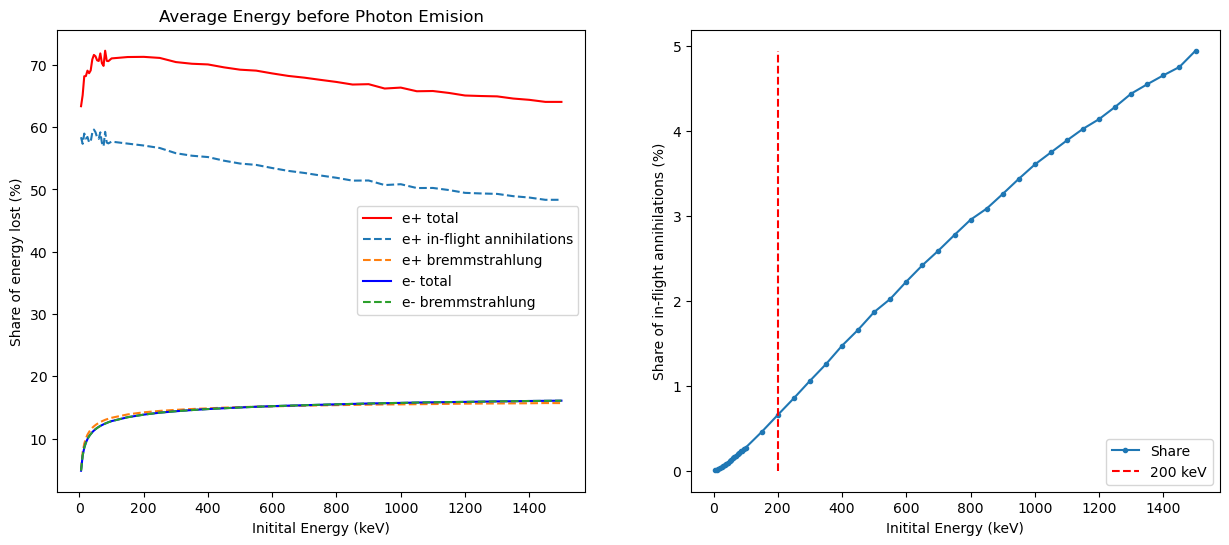

In [75]:
in_flights = np.array(in_flights)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(ener_range, (np.array(avg_bremss[:,1])+np.array(in_flights[:,1]))/ener_range*100, 'r-', label='e+ total')
plt.plot(ener_range, in_flights[:,1]/ener_range*100, '--', label='e+ in-flight annihilations')
plt.plot(ener_range, avg_bremss[:,1]/ener_range*100, '--', label='e+ bremmstrahlung')
plt.plot(ener_range, avg_bremss[:,0]/ener_range*100, 'b-', label='e- total')
plt.plot(ener_range, avg_bremss[:,0]/ener_range*100, '--', label='e- bremmstrahlung')
plt.legend()
# plt.yscale('log')
plt.xlabel('Initital Energy (keV)')
plt.ylabel('Share of energy lost (%)')
plt.title('Average Energy before Photon Emision')

plt.subplot(1, 2, 2)
plt.plot(ener_range, in_flights[:,0], '.-', label='Share')
plt.vlines(200, 0, in_flights[:,0].max(), colors='r', linestyles='dashed', label='200 keV')
plt.legend(loc='lower right')
plt.xlabel('Initital Energy (keV)')
plt.ylabel('Share of in-flight annihilations (%)')
plt.show()


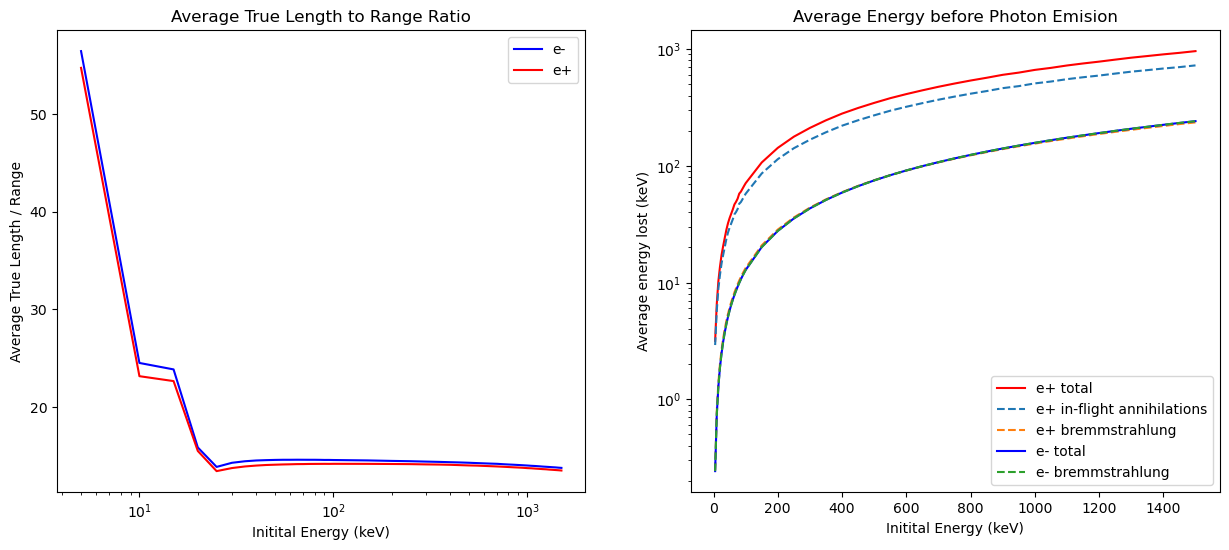

In [69]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(ener_range, 1/avg_TRratio[:,0], 'b-', label='e-')
plt.plot(ener_range, 1/avg_TRratio[:,1], 'r-', label='e+')
plt.legend()
plt.xlabel('Initital Energy (keV)')
plt.ylabel('Average True Length / Range')
plt.title('Average True Length to Range Ratio')
plt.xscale('log')
plt.ylim(None, None)
plt.xlim(0, None)

plt.subplot(1, 2, 2)
in_flights = np.array(in_flights)
plt.plot(ener_range, np.array(avg_bremss[:,1])+np.array(in_flights[:,1]), 'r-', label='e+ total')
plt.plot(ener_range, in_flights[:,1], '--', label='e+ in-flight annihilations')
plt.plot(ener_range, avg_bremss[:,1], '--', label='e+ bremmstrahlung')
plt.plot(ener_range, avg_bremss[:,0], 'b-', label='e- total')
plt.plot(ener_range, avg_bremss[:,0], '--', label='e- bremmstrahlung')
plt.legend()
plt.yscale('log')
plt.xlabel('Initital Energy (keV)')
plt.ylabel('Average energy lost (keV)')
plt.title('Average Energy before Photon Emision')
plt.show()


In [1]:
EMAX = 4e3  # keV
dens = 1.0  # g/cm3

### Probabilities from PENELOPE tables ###
TCS = np.loadtxt("../PositronPhysics/water/TCSp.tab")
STP = np.loadtxt("../PositronPhysics/water/STPp.tab")
TCS[:,0] /= 1e3   # eV to keV
STP[:,:4] /= 1e3  # eV to keV
STP[:,1:4] *= dens # from keV/(g/cm2) to keV/cm

ne = 6.022e23 * 1/18   # electrons per cm3 for water 
SP = STP[:,3]
CSann = TCS[:,4] # 1:el, 2:in, 3:br, 4:an, 5:tot, 6:isi 
I = ne * CSann / SP  # annihilation probability per unit of energy loss
# normI = np.trapz(I, TCS[:,0])
# I /= normI  # normalized

mask = TCS[:,0]<=EMAX 
E = TCS[:,0][mask]
I = I[mask]
CSann = CSann[mask]

### Primary physical quantities ###
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(E/1e3, ne*CSann, 'g.', label='Annihilation Attenuation (1/cm)')
plt.plot(E/1e3, I, 'b.', label='Total Stopping Power (keV/cm)')
plt.xlabel('Positron Energy (MeV)')
plt.ylabel('Value')
plt.title('Primary Physical Quantities for Positrons in Water')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylim(0, 10)
plt.xlim(5e-2/1e3, EMAX/1e3)

### Positron annihilation probability calculation ###
energies = np.arange(0, int(EMAX+1), 0.01)
intensity = np.interp(energies, E, I)

plt.subplot(1, 3, 2)
plt.plot(E/1e3, I, 'r.', label='PENELOPE')
plt.plot(energies/1e3, intensity, 'b-', label='Interpolated')
plt.xlabel('Positron Energy (MeV)')
plt.ylabel('mu(E) / S(E) ')
plt.title('Positron Annihilation Probability in Water')
plt.legend()
plt.xscale('log')
plt.xlim(5e-2/1e3, EMAX/1e3)

### Expected in-flight annihilation probabilities ###
probs = []
E0 = 0
ener_range = list(range(5, 100, 5)) + list(range(100, int(EMAX+1), 50))
for E1 in ener_range:
    interval = np.logical_and(energies>=E0, energies<=E1)
    tau = np.trapezoid(intensity[interval], energies[interval], dx=1)
    expected_prob = 1 - np.exp(-tau)
    probs.append(expected_prob)
    # print(f"Expected in-flight probability from {E0} to {E1} keV: {expected_prob*100:>4.2f}% ({expected_prob*1e6:.0f} per million interactions)")

ener_range = np.array(ener_range)
probs = np.array(probs)

plt.subplot(1, 3, 3)
plt.plot(ener_range/1e3, probs*100, '.-', label='In-flight Share')
plt.xlabel('Initial Energy (MeV)')
plt.ylabel('In-flight Annihilation Expected Share (%)')
plt.title('Expected In-flight Annihilation Probability in Water')
plt.legend()
plt.xscale('log')
plt.xlim(ener_range[0]/1e3, EMAX/1e3)
plt.show()

### Probabilities from MC simulation ###
# Eloss = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/e+/{E1}keV-eloss.dat") 
# simulated_prob = np.count_nonzero(Eloss[:,3])/len(Eloss[:,3])
# print(f"Simulated in-flight probability up to {E1} keV:     {simulated_prob*100:>4.2f}% ({simulated_prob*1e6:.0f} per million interactions)")

NameError: name 'np' is not defined

Average hard inelastic loss: 8.231e+02 keV/history
Average hard bremms loss:    3.466e+00 keV/history
Average ionization loss:     1.551e+02 keV/history
Average annihilation loss:   1.000e+03 keV/history

Probability of at least 1 hard inelastic event:  0.999997
Probability of at least 1 bremmstrahlung event:  0.160381
Probability of at least 1 ionization event:      0.999651
Probability of at least 1 annihilation event:    1.000000
In-flight annihilations:     3.61%


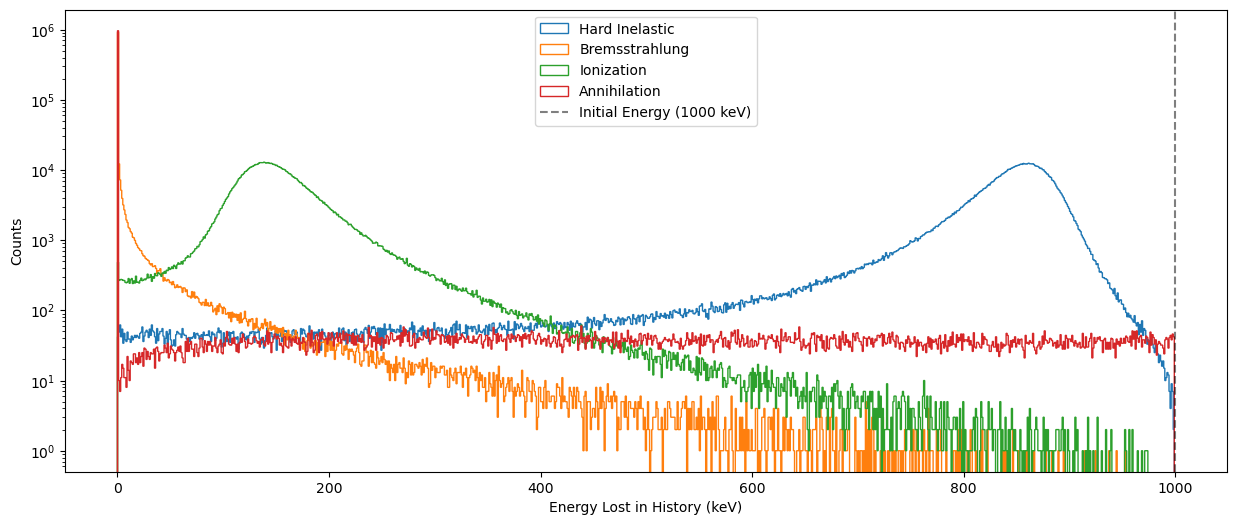

In [38]:
### Probabilities from simulation ###
plt.figure(figsize=(15, 6))

PAR = "Pos"
ener = 1000

Eloss = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-eloss.dat")/1e3    # keV
Range = fitPRd.load_sample(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-range.dat") # mm

hardIn  = Eloss[:,0]
hardBr  = Eloss[:,1]
innIon  = Eloss[:,2]
annihil = Eloss[:,3]

print(f"Average hard inelastic loss: {np.mean(hardIn):.3e} keV/history")
print(f"Average hard bremms loss:    {np.mean(hardBr):.3e} keV/history")
print(f"Average ionization loss:     {np.mean(innIon):.3e} keV/history")
print(f"Average annihilation loss:   {np.max(annihil):.3e} keV/history")
print()
print(f"Probability of at least 1 hard inelastic event:  {len(hardIn[hardIn>0])/len(annihil):.6f}")
print(f"Probability of at least 1 bremmstrahlung event:  {len(hardBr[hardBr>0])/len(annihil):.6f}")
print(f"Probability of at least 1 ionization event:      {len(innIon[innIon>0])/len(annihil):.6f}")
print(f"Probability of at least 1 annihilation event:    {len(annihil)/len(annihil):.6f}")
print(f"In-flight annihilations:     {len(annihil[annihil>0])/len(annihil)*100:.2f}%")

for test, label in zip([hardIn, hardBr, innIon, annihil], ['Hard Inelastic', 'Bremsstrahlung', 'Ionization', 'Annihilation']):
    # if label != 'Bremsstrahlung': continue
    plt.hist(test, bins=np.arange(test.min(), test.max()), range=(0, test.max()), histtype='step', label=f'{label}')
plt.axvline(x=ener, color='k', linestyle='--', alpha=0.5, label=f'Initial Energy ({ener} keV)')
plt.xlabel('Energy Lost in History (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()
# plt.xlim(180, 220)
# plt.ylim(10, 50)
plt.show()

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:07<00:00,  1.98it/s]


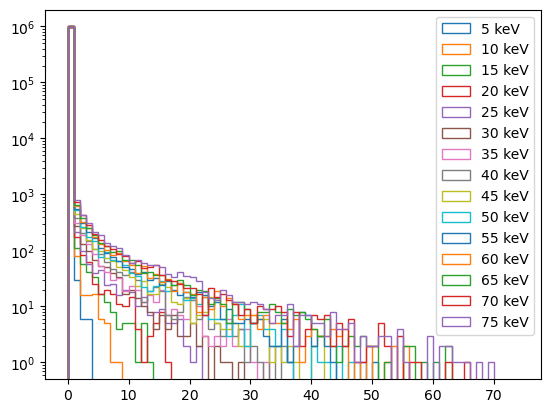

In [4]:
PAR = 'Pos'
ener_range = list(range(5, 80, 5))
for ener in  tqdm(ener_range, disable=False):
    # if ener % 500 != 0:
    #     continue
    delta = 5 if ener < 100 else 50
    # print(f"---Energy: {ener} keV")
    Eloss = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-eloss.dat")/1e3    # keV
    Range = fitPRd.load_sample(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-range.dat") # mm
    
    hardIn = Eloss[:,0]
    hardBr = Eloss[:,1]
    innIon = Eloss[:,2]
    annihil = Eloss[:,3]

    # plt.hist(annihil[annihil>0], histtype='step', label=f"{ener} keV")
    plt.hist(hardBr, histtype='step', label=f"{ener} keV", bins=np.arange(0, ener, 1))
    plt.legend()
    plt.yscale('log')

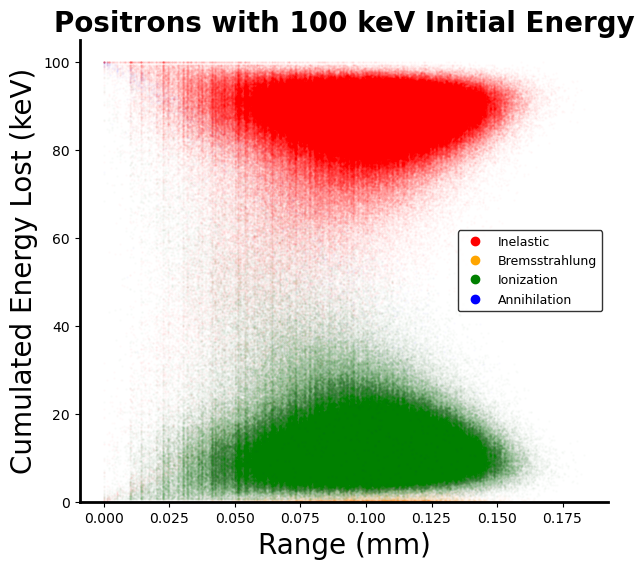

In [77]:
from analysis import aesthetic_plot
ener_range = list(range(5, 100+1, 5)) + list(range(100, 1500+1, 50))
ener_range = [100,]

plt.figure(figsize=(15, 6)); __k=0
for PAR in ['Pos']:
    plt.subplot(1, 2, __k+1); __k+=1
    for ener in tqdm(ener_range, disable=True):
        # if ener % 500 != 0:
        #     continue
        delta = 5 if ener < 100 else 50
        Eloss = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-eloss.dat")/1e3    # keV
        Range = fitPRd.load_sample(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-range.dat")*10 # mm
        TL = np.loadtxt(f"RESULTS/PRofE/Water/PenEasy2024_xyz/{'e+' if PAR=='Pos' else 'e-'}/{ener}keV-nint.dat")[:,4]*10  # mm
        X = Range

        # bins_range = np.arange(0, Range.max(), 0.01)
        # bins_ener = np.arange(0, ener, 1)
        
        hardIn = Eloss[:,0]
        hardBr = Eloss[:,1]
        innIon = Eloss[:,2]
        annihil = Eloss[:,3]

        # HH, _, _ = np.histogram2d(Range, hardBr, bins=[bins_range, bins_ener])
        # HH[HH>10] = 10
        
        ALPHA = 0.01
        plt.scatter(X[hardIn>0], hardIn[hardIn>0], s=1, alpha=ALPHA, color='red')
        plt.scatter(X[hardBr>0], hardBr[hardBr>0], s=1, alpha=ALPHA, color='orange')
        plt.scatter(X[innIon>0], innIon[innIon>0], s=1, alpha=ALPHA, color='green')
        if PAR == 'Pos': plt.scatter(X[annihil>0], annihil[annihil>0], s=1, alpha=ALPHA, color='blue')


    plt.plot([], [], 'o', color='red', label='Inelastic')
    plt.plot([], [], 'o', color='orange', label='Bremsstrahlung')
    plt.plot([], [], 'o', color='green', label='Ionization')
    if PAR == 'Pos': plt.plot([], [], 'o', color='blue', label='Annihilation')
    plt.legend()
    plt.title(f"{'Positrons' if PAR=='Pos' else 'Electrons'} with {ener} keV Initial Energy")
    plt.xlabel("Range (mm)")
    plt.ylabel('Cumulated Energy Lost (keV)')
    ax, leg = aesthetic_plot()
    ax.grid(False)
    leg.set_loc('center right')
    # plt.colorbar(label='Counts')
    # plt.xscale('log')
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:00<00:00, 23430.43it/s]


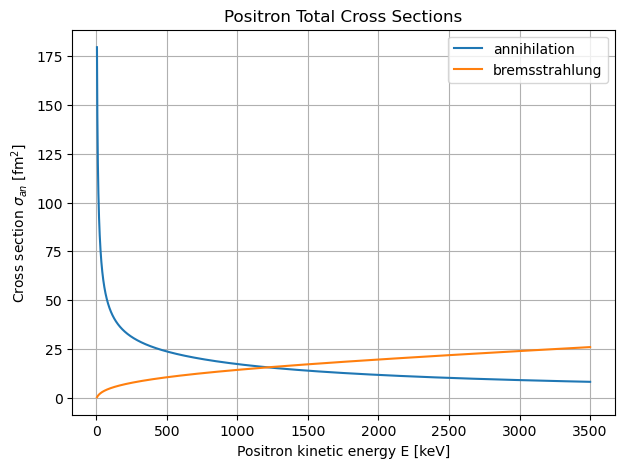

Text(0.5, 1.0, 'Ratio of Annihilation to Bremsstrahlung Cross Sections')

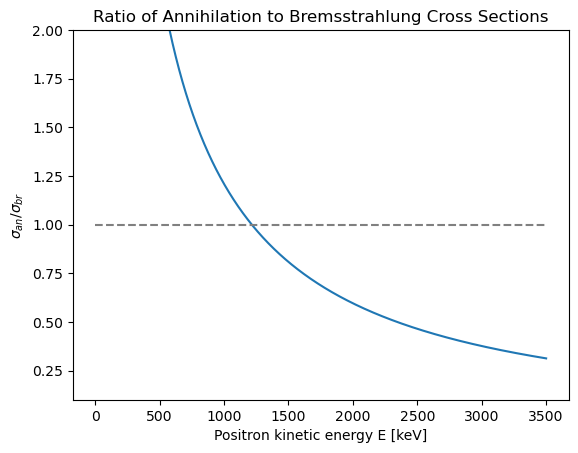

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from tqdm import tqdm

# Constants
alpha = 1/137.035999    # fine-structure constant
re = 2.8179403227  # classical electron radius [fm]
mc2 = 510.998950 # electron rest mass energy [keV]

def sigma_an(E):
    """Heitler formula for positron annihilation cross section.
    E in keV (kinetic energy), returns σ in m^2."""
    gamma = E / mc2 + 1.0
    term1 = (gamma**2 + 4*gamma + 1) / (gamma**2 - 1)
    term2 = np.log(gamma + np.sqrt(gamma**2 - 1))
    term3 = (gamma + 3) / np.sqrt(gamma**2 - 1)
    return (np.pi * re**2 / (gamma + 1)) * (term1 * term2 - term3)

def sigma_bh(E, Z=1):
    """
    Bethe-Heitler total cross section (unscreened).
    E : kinetic energy [keV]
    k : photon energy [keV]
    Z : atomic number
    Returns \int_1^0.999E dσ/dk dk in [fm^2 / keV].
    """
    # Vectorized implementation for efficiency
    E = np.atleast_1d(E)
    SS = np.zeros_like(E)
    n_k = 1000  # Number of k points for integration

    for idx, e in enumerate(tqdm(E)):
        if e <= 1.0:
            SS[idx] = 0.0
            continue
        k = np.linspace(1.0, e * 0.999, n_k)  # photon energy [keV]
        y = k / e
        prefactor = 4 * Z**2 * re**2 * alpha / k
        term1 = 1 + (1 - y) ** 2
        term2 = np.log(2 * (e + mc2) * (1 - y) / (mc2 * y))
        term3 = (1 - y)
        dS = prefactor * (term1 * term2 - term3)
        SS[idx] = np.trapz(dS, k)
    return SS

# Parameters
E = np.linspace(5, 3500, 10000)  # positron kinetic energy in keV

# Compute cross section
S_anh = sigma_an(E)
S_brm = sigma_bh(E)

# Plot
plt.figure(figsize=(7,5))
plt.plot(E, S_anh, label="annihilation")
plt.plot(E, S_brm, label="bremsstrahlung")
plt.xlabel("Positron kinetic energy E [keV]")
plt.ylabel(r"Cross section $\sigma_{an}$ [fm$^2$]")
plt.title("Positron Total Cross Sections")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(E, S_anh/S_brm)
plt.ylim(0.1, 2)
plt.hlines(xmin=0, xmax=3500, y=1, color='gray', linestyle='--')
# plt.yscale('log')
plt.xlabel("Positron kinetic energy E [keV]")
plt.ylabel(r"$\sigma_{an}/\sigma_{br}$")
plt.title("Ratio of Annihilation to Bremsstrahlung Cross Sections")

## Weibull Paper Plot

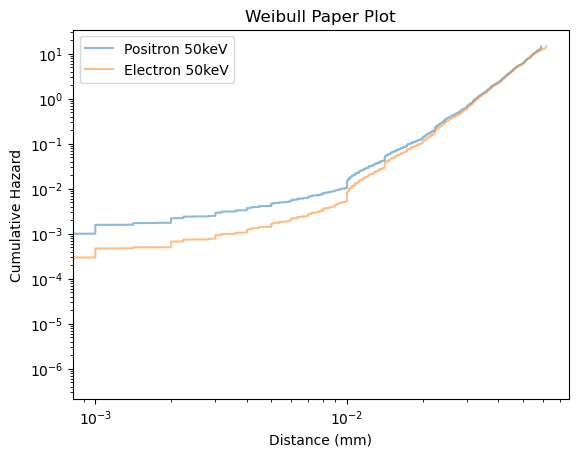

In [14]:
import fitPRd
import matplotlib.pyplot as plt
import numpy as np
ener = 50
PR, PG = fitPRd.load_nonhisto_G3D(f"RESULTS/PRofE/Water/PenEasy2024_xyz/e+/{ener}keV-range.dat")
ER, EG = fitPRd.load_nonhisto_G3D(f"RESULTS/PRofE/Water/PenEasy2024_xyz/e-/{ener}keV-range.dat")
PR *= 10  # Convert to mm
ER *= 10  # Convert to mm

plt.plot(PR, -np.log(1-PG), '-', label=f'Positron {ener}keV', markersize=2.5, alpha=0.5)
plt.plot(ER, -np.log(1-EG), '-', label=f'Electron {ener}keV', markersize=2.5, alpha=0.5)
plt.xlabel('Distance (mm)')
plt.ylabel('Cumulative Hazard')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.title("Weibull Paper Plot")
plt.show()

# ANALYSIS

In [42]:
import os, numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
import fitPRd, betaplus
from analysis import iso_in_plots, aesthetic_plot
import psutil
from tqdm import tqdm

folder = "RESULTS/PRofE/Water/PenEasy2024_xyz/"
EMAX = 1500  # keV
RMIN = 0.01  # mm

data_e = dict()
data_p = dict()
for particle in ["e+", "e-"]:
    directory = os.path.join(folder, particle)
    if os.path.exists(directory):
        files = os.listdir(directory)
        energies = set([int(f.split("keV")[0]) for f in files])
        energies = sorted(list(energies))
        files = {e: [f"{e}keV-range.dat", f"{e}keV-eloss.dat"] for e in energies} 

        print(f"Files in {directory}:")
        print(f"  - {len(files)} energies found")
        print(f"  - Energies: {','.join(map(str, energies))} keV")
    else:
        print(f"Directory {directory} does not exist.")
        exit(1)

    print()

    data = data_e if particle == "e-" else data_p if particle =='e+' else dict()
    for E, (frange, feloss) in tqdm(files.items(), leave=False):
        if int(E) > EMAX: continue
        RANGE = fitPRd.load_sample(os.path.join(directory, frange)) * 10    # cm to mm
        if RANGE.ndim == 1:
            RANGE = RANGE[:, None]
        ELOSS = np.loadtxt(os.path.join(directory, feloss))

        # Apply RMIN filter
        mask = (RANGE >= RMIN).flatten()
        RANGE = RANGE[mask]  
        ELOSS = ELOSS[mask]
        if RANGE.size <= (_:=10):
            print(f"Warning: Not enough data points ({_}) above RMIN={RMIN} mm for {E} keV in {particle}. Skipping.")
            continue
        data[E] = np.hstack([RANGE, ELOSS])    # mm
        # print(f"Loaded data for {E} keV: {data[E].shape}")
    
# Colors
Emax_e = max(data_e.keys())
Emax_p = max(data_p.keys())
colors_e = {E: plt.cm.viridis(E / Emax_e) for E in data_e.keys()}
colors_p = {E: plt.cm.plasma(E / Emax_p) for E in data_p.keys()}

# RAM used by this Python process
process = psutil.Process(os.getpid())
rss = process.memory_info().rss  # in bytes
print(f"\n\nCurrent Python process RAM usage: {rss/1e9:.2f} GB")

# Total system RAM usage, not just this Python program.
mem = psutil.virtual_memory()
print(f"RAM usage: {mem.percent:.1f}% used, {mem.used/1e9:.2f}GB/{mem.total/1e9:.2f}GB")


Files in RESULTS/PRofE/Water/PenEasy2024_xyz/e+:
  - 88 energies found
  - Energies: 5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,2600,2650,2700,2750,2800,2850,2900,2950,3000,3050,3100,3150,3200,3250,3300,3350,3400,3450,3500 keV



  0%|          | 0/88 [00:00<?, ?it/s]

  1%|          | 1/88 [00:00<00:37,  2.30it/s]

  2%|▏         | 2/88 [00:00<00:38,  2.23it/s]

Files in RESULTS/PRofE/Water/PenEasy2024_xyz/e-:
  - 88 energies found
  - Energies: 5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800,850,900,950,1000,1050,1100,1150,1200,1250,1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,2300,2350,2400,2450,2500,2550,2600,2650,2700,2750,2800,2850,2900,2950,3000,3050,3100,3150,3200,3250,3300,3350,3400,3450,3500 keV



  1%|          | 1/88 [00:00<00:36,  2.37it/s]

  2%|▏         | 2/88 [00:00<00:37,  2.27it/s]



Current Python process RAM usage: 4.62 GB
RAM usage: 6.8% used, 8.30GB/134.70GB


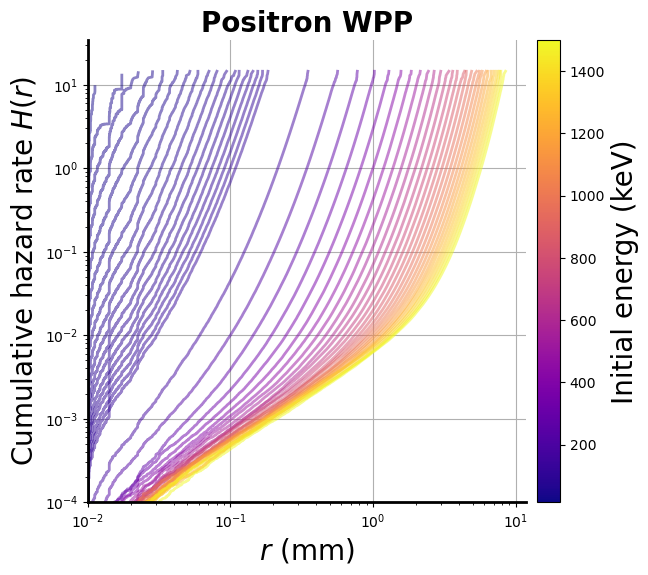

In [43]:
plt.figure(figsize=(15, 6)); __k=1
for data, colors in zip([data_p], [colors_p]):
    plt.subplot(1, 2, __k); __k += 1
    plt.title(f"{'Electron' if data is data_e else 'Positron'} WPP")
    for E in list(data.keys()):
        # if not (0 < E < 2000): continue
        sorted_PRs = np.sort(data[E][:,0]).astype(float)
        G3D = (np.arange(1, len(sorted_PRs) + 1) - 0.5) / len(sorted_PRs)
        
        delta = sorted_PRs[-1] - sorted_PRs[-2]

        x = sorted_PRs
        y = -np.log(1-G3D)  # H(r) cumulative hazard rate

        plt.plot(x, y, '-', label=f"{E} keV", lw=2, alpha=0.5, color=colors[E])
    plt.xlabel(r"$r$ (mm)")
    plt.ylabel(r"Cumulative hazard rate $H(r)$")
    plt.xscale('log')
    plt.yscale('log')
    sm = plt.cm.ScalarMappable(cmap=(plt.cm.viridis if colors is colors_e else plt.cm.plasma), 
                               norm=mcolors.Normalize(vmin=list(colors.keys())[0], vmax=list(colors.keys())[-1]))
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    ax, leg = aesthetic_plot()
    leg.set_visible(False)
    cbar.set_label('Initial energy (keV)', fontsize=20)
    plt.ylim(1e-4, None)
    plt.xlim(RMIN, None)
plt.show()

Fitting data for e+ ...
Fit parameters for   60 keV: a1=7.91e+00, k1=1.92, a2=2.16e+01, k2=4.77		(MAPE=10.52%)
Fit parameters for   65 keV: a1=8.67e+00, k1=2.17, a2=1.86e+01, k2=4.89		(MAPE=6.85%)
Fit parameters for   70 keV: a1=6.34e+00, k1=1.91, a2=1.65e+01, k2=4.92		(MAPE=7.24%)
Fit parameters for   75 keV: a1=6.91e+00, k1=2.14, a2=1.45e+01, k2=5.05		(MAPE=4.71%)
Fit parameters for   80 keV: a1=6.48e+00, k1=2.18, a2=1.29e+01, k2=5.14		(MAPE=4.04%)
Fit parameters for   85 keV: a1=6.35e+00, k1=2.29, a2=1.16e+01, k2=5.22		(MAPE=2.97%)
Fit parameters for   90 keV: a1=6.61e+00, k1=2.53, a2=1.04e+01, k2=5.36		(MAPE=1.74%)
Fit parameters for   95 keV: a1=5.57e+00, k1=2.39, a2=9.54e+00, k2=5.35		(MAPE=2.05%)
Fit parameters for  100 keV: a1=6.07e+00, k1=2.73, a2=8.60e+00, k2=5.52		(MAPE=0.78%)
Fit parameters for  150 keV: a1=3.45e+00, k1=3.02, a2=4.27e+00, k2=6.02		(MAPE=0.63%)
Fit parameters for  200 keV: a1=2.19e+00, k1=3.12, a2=2.67e+00, k2=6.24		(MAPE=0.59%)
Fit parameters for  250 keV: 

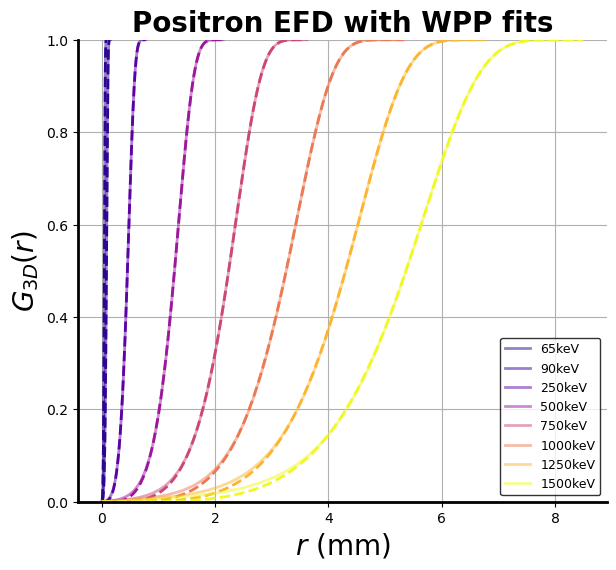

In [ ]:
import stats
import lmfit

params_e = np.zeros((len(data), 1+6))
def fit_func_e(x, a1, k1, a2, k2, a3, k3):
    return k1*(a1*x)**k1 + k2*(a2*x)**k2 + k3*(a3*x)**k3

params_p = np.zeros((len(data), 1+4))
def fit_func_p(x, a1, k1, a2, k2):
    return (a1*x)**k1 + (a2*x)**k2

params_t = np.zeros((len(data), 1+2))
def fit_func_t(x, a1, k1):
    return k1*(a1*x)**k1

eps = 0.99

plt.figure(figsize=(15, 6)); __k=1
for data, colors, fit_func, params in [(data_e, colors_e, fit_func_e, params_e), (data_p, colors_p, fit_func_p, params_p)]:
    if data is not data_p: continue
    print(f"Fitting data for {'e+' if data is data_p else 'e-'} ...")
    plt.subplot(1, 2, __k); __k += 1
    ff = (params.shape[1] - 1) // 2  # number of fit parameters pairs (a,k)
    prev_popt = None
    for nit, (E, info) in enumerate(data.items()):
        sorted_PRs = np.sort(info[:,0]).astype(float)
        # if nit % 2 != 0: continue
        # if E < 60: continue
        G3D = (np.arange(1, len(sorted_PRs) + 1) - 0.5) / len(sorted_PRs)

        x = sorted_PRs
        y = -np.log(1-G3D)  # H(r) cumulative hazard rate

        M = lmfit.Model(fit_func)
        P = lmfit.Parameters()
        for i in range(ff):     
            """ customize for energie (set a1=np.inf when E<100) and particle (save e- popt for e+ and fix) """
            # coefficients
            if E < 100:
                if i == 0:
                    amax = np.inf
                amax = np.inf #if not prev_popt else prev_popt[2*i]
                amin = 0
                a0 = 100.0
                P.add(f'a{i+1}', value=a0, min=amin, max=amax)
            # exponents
            if E < 60:
                k0 = 1.001 + i*1.0
                P.add(f'k{i+1}', value=k0, vary=False)
            elif not prev_popt:
                kmin, kmax, k0 = 0, 10, 2*i+2.5
                P.add(f'k{i+1}', value=k0, min=kmin, max=kmax) 
            else:
                kmin = max(1.001, prev_popt[2*i+1] - 0.5)
                kmax = max(1.500, prev_popt[2*i+1] + 0.5)
                k0 = (kmin+kmax)/2
                P.add(f'k{i+1}', value=k0, min=kmin, max=kmax)

        R = M.fit(y, P, x=x)
        popt_pairs = [(R.best_values[f'a{i+1}'], 
                       R.best_values[f'k{i+1}']) 
                       for i in range(ff)]
        popt_pairs = sorted(popt_pairs, key=lambda x: x[1])
        popt_flat = [val for pair in popt_pairs for val in pair]
        prev_popt = popt_flat
        
        params[nit, 0] = E
        for i in range(ff):
            params[nit, 1+i*2:1+(i+1)*2] = [1/popt_flat[i*2], popt_flat[i*2+1]]
            
        ss = ", ".join(f"a{i+1}={popt_flat[i*2]:.2e}, k{i+1}={popt_flat[i*2+1]:<4.2f}" 
                  for i in range(ff))
        
        # if fit_func is fit_func_e:
        #     params_p[nit, :-2] = params_e[nit, :]

        XX = sorted_PRs
        YY_model = 1 - np.exp(-fit_func(sorted_PRs, *popt_flat))
        YY_exp = G3D
        print(f"Fit parameters for {E:>4n} keV: {ss}\t\t(MAPE={stats.MAPE(YY_model, YY_exp):.2f}%)")
        if nit % 10 == 0:
            plt.plot(XX, YY_exp, '-', label=f"{E}keV", lw=2, alpha=0.5, color=colors[E])   # -np.log(1-G3D)
            plt.plot(XX, YY_model, '--', lw=2, color=colors[E])       # fit_func(x, *popt)
            plt.title(f"{'Electron' if data is data_e else 'Positron'} EFD with WPP fits")
        
        plt.xlabel(r"$r$ (mm)")
        plt.ylabel(r"$G_{3D}(r)$")
        # plt.yscale('log')
        plt.legend()
        aesthetic_plot()

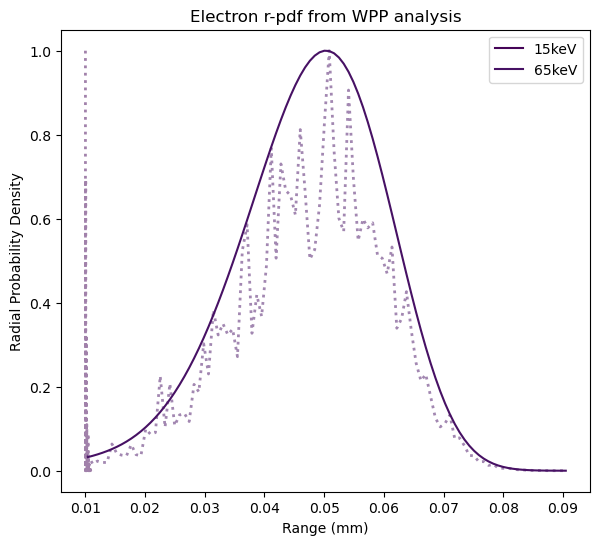

In [16]:
def g3D_func_e(x, l1, k1, l2, k2):
    term  = (x/l1)**k1               + (x/l2)**k2
    dterm = k1/l1 * (x/l1)**(k1 - 1) + k2/l2 * (x/l2)**(k2 - 1)
    return np.exp(-term) * dterm

def g3D_func_p(x, l1, k1, l2, k2, l3, k3):
    term  = k1 * (x/l1)**k1               + k2 * (x/l2)**k2               + k3 * (x/l3)**k3
    dterm = k1 * k1/l1 * (x/l1)**(k1 - 1) + k2 * k2/l2 * (x/l2)**(k2 - 1) + k3 * k3/l3 * (x/l3)**(k3 - 1)
    return np.exp(-term) * dterm

plt.figure(figsize=(15, 6)); __k=1
for data, colors, g3D_func, params in [(data_e, colors_e, g3D_func_e, params_e), (data_p, colors_p, g3D_func_e, params_p)]:
    if data is data_p: continue
    plt.subplot(1, 2, __k); __k += 1
    for nit, E in enumerate(data.keys()):
        if nit%10 != 0: continue
        if E > 100: continue
        RANGE = data[E][:,0]  # mm
        hist, bin_edges = np.histogram(RANGE, bins=100, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        hist /= np.max(hist)  # Normalize the histogram
        plt.plot(bin_centers, hist, ':', lw=2, alpha=0.5, color=colors[E])

        # Compute the theoretical g3D distribution
        g3D_model = g3D_func(bin_centers, *params[nit, 1:])
        g3D_model /= np.max(g3D_model)  # Normalize the theoretical distribution
        plt.plot(bin_centers, g3D_model, '-', label=f"{E}keV", lw=1.5, color=colors[E])
        
        # LAMBDA = np.mean(PRs) / (np.std(PRs)/(2*np.sqrt(2*np.log(2))))  # FWHM
        # print(f"Mean PR for {E} keV: {np.mean(PRs):.2e} mm, Lambda: {LAMBDA:.2e}")
        # # Compute Poisson distribution using mean_PR as lambda
        # k = np.arange(1, len(bin_centers) + 1)
        # poisson = (LAMBDA ** k) * np.exp(-LAMBDA) / factorial(k)
        # poisson /= np.max(poisson)  # Normalize
        
        # # Plot the Poisson fit as a dashed line
        # plt.plot(bin_centers, poisson, '-', label=f"{E}keV Poisson Fit", lw=1.5)   
        # break
        
    plt.xlabel("Range (mm)")
    plt.ylabel("Radial Probability Density")
    plt.title(f"{'Electron' if data is data_e else 'Positron'} r-pdf from WPP analysis")
    plt.legend()

plt.show()

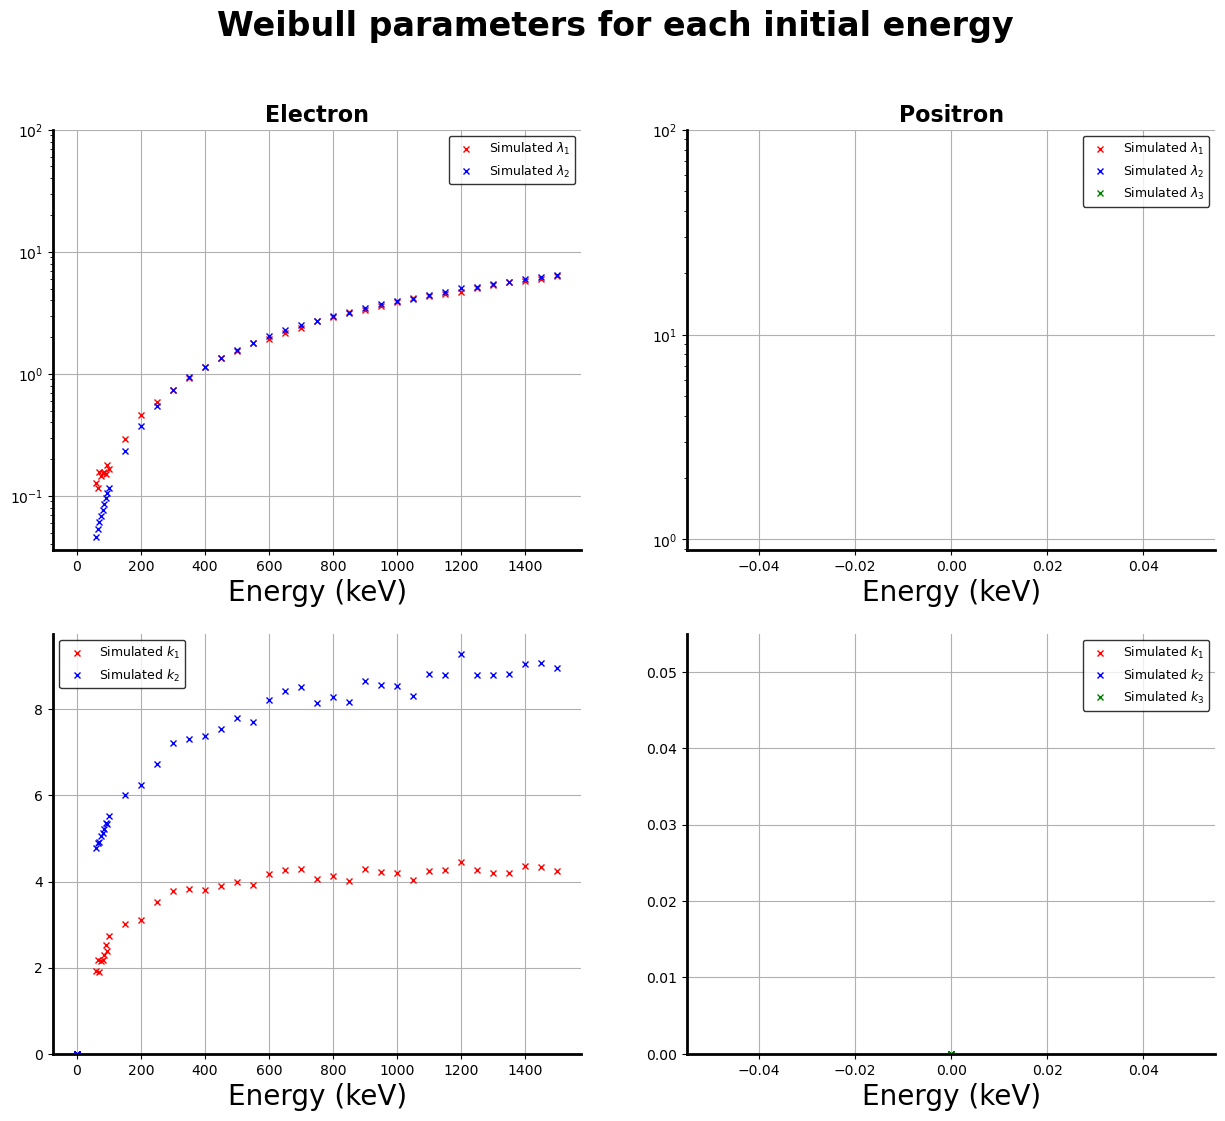

In [76]:
# Define the fitting functions
def lambda_func(x, A, B):
    return A * x**B #A*(np.sqrt(x**2 + B**2) - B)

def n_func1(x, A, B):
    return A * np.log(1 + B*x)

def n_func2(x, A, B, C):
    return A * np.log(1 + B*x) #- C*x  # A * np.log(1 + B*x) - C*x

plt.figure(figsize=(15, 12)); __k=1
plt.suptitle("Weibull parameters for each initial energy", fontsize=24, fontweight='bold')
plt.gca().set_axis_off()
for params in [params_e, params_p]:
    pp = params[0:, ...]
    plt.subplot(2, 2, __k); __k += 2
    # Fit and plot parameter "a" with an exponential function
    for i, c in zip(range(1, pp.shape[1], 2), ['red', 'blue', 'green']):
        plt.plot(pp[:, 0], pp[:, i], 'x', markersize=5, color=c, label=rf"Simulated $\lambda_{(i+1)//2}$")

    # popt_l1, _ = curve_fit(lambda_func, pp[:, 0], pp[:, 1], p0=[1, 0.001])
    # plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l1), 'k-', lw=5, zorder=10)  # label=r"Model Fit: $\lambda_1$"
    # print("Fit for a1: A = %.2e, B = %.2e" % (popt_l1[0], popt_l1[1]))

    # popt_l2, _ = curve_fit(lambda_func, pp[:, 0], pp[:, 3], p0=[1, 0.001])
    # plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l2), 'k-', label=r"Model Fits", lw=5, zorder=10)
    # print("Fit for a2: A = %.2e, B = %.2e" % (popt_l2[0], popt_l2[1]))

    plt.xlabel("Energy (keV)")
    # plt.ylabel(r"$\lambda$", rotation=0)
    plt.yscale('log')
    plt.legend()
    ax, leg = aesthetic_plot()
    ax.set_ylim(-0., 100)
    # ax.set_xlim(0, 500)
    plt.title(f"{'Electron' if params is params_e else 'Positron'}", fontsize=16, fontweight='bold')

    # Fit and plot parameter "n" with a logarithmic function
    plt.subplot(2, 2, __k); __k -= 1
    for i, c in zip(range(2, pp.shape[1], 2), ['red', 'blue', 'green']):
        plt.plot(pp[:, 0], pp[:, i], 'x', markersize=5, color=c, label=rf"Simulated $k_{(i+1)//2}$")

    # popt_n1, _ = curve_fit(n_func2, pp[:, 0], pp[:, 2], p0=(1, 1, 1))
    # plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n1), 'k-', lw=5, zorder=10)
    # print("Fit for n1: A = %.2e, B = %.2e, C = %.2e" % (popt_n1[0], popt_n1[1], popt_n1[2]))

    # popt_n2, _ = curve_fit(n_func2, pp[:, 0], pp[:, 4], p0=(1, 1, 1))
    # plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n2), 'k-', lw=5, zorder=10, label="Model Fits")
    # print("Fit for n2: A = %.2e, B = %.2e, C = %.2e" % (popt_n2[0], popt_n2[1], popt_n2[2]))

    plt.xlabel("Energy (keV)")
    # plt.ylabel(r"$k$", rotation=0)
    # plt.yscale('log')
    plt.legend()
    ax, leg = aesthetic_plot()
    # ax.set_xlim(0, 100)

R2 for C11: 0.309
MAPE for C11: 2507.6 %
Mean simulated PR for C11: 0.65 mm
Mean generated PR for C11: 1.45 mm (123.1%)
----------------------
R2 for N13: 0.346
MAPE for N13: 2756.4 %
Mean simulated PR for N13: 1.05 mm
Mean generated PR for N13: 1.95 mm (85.7%)
----------------------
R2 for O15: 0.383
MAPE for O15: 10291.6 %
Mean simulated PR for O15: 1.85 mm
Mean generated PR for O15: 3.35 mm (81.1%)
----------------------
R2 for F18: 0.242
MAPE for F18: 3225.4 %
Mean simulated PR for F18: 0.35 mm
Mean generated PR for F18: 0.75 mm (114.3%)
----------------------
R2 for Cu64: 0.145
MAPE for Cu64: 2640.6 %
Mean simulated PR for Cu64: 0.35 mm
Mean generated PR for Cu64: 0.95 mm (171.4%)
----------------------
R2 for Ga68: 0.363
MAPE for Ga68: 4259.3 %
Mean simulated PR for Ga68: 2.25 mm
Mean generated PR for Ga68: 3.85 mm (71.1%)
----------------------
R2 for Rb82: 0.282
MAPE for Rb82: 1047.7 %
Mean simulated PR for Rb82: 4.75 mm
Mean generated PR for Rb82: 7.65 mm (61.1%)
-------------

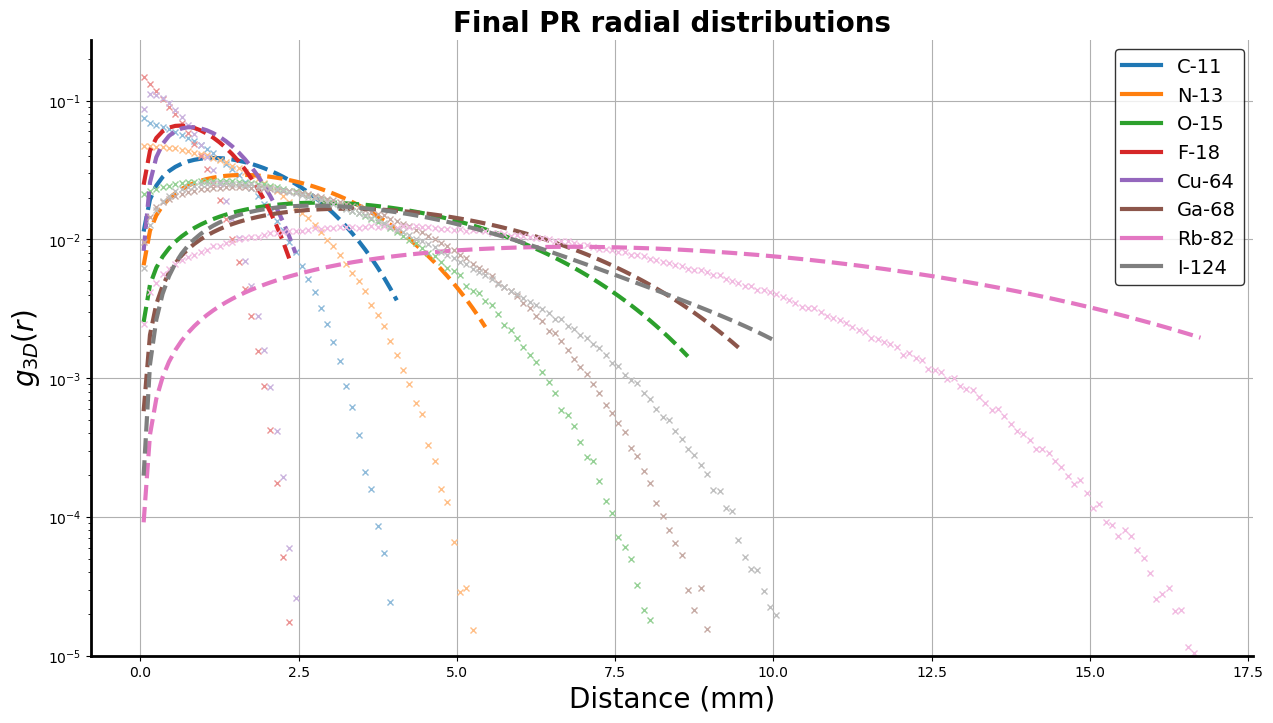

In [10]:
from matplotlib.lines import Line2D

##############################################################################################################################
# plt.figure(figsize=(15, 6))
# # plt.subplot(1, 3, (1, 2))
# plt.subplot(1, 2, 1)
# plt.title("A. Weibull parameters", fontsize=24, fontweight='bold', loc='center')
# # plt.gca().set_axis_off()
# plt.plot(pp[:, 0], pp[:, 1], 'x', markersize=5, color="red", label=r"$\lambda_1$")
# plt.plot(pp[:, 0], pp[:, 3], 'x', markersize=5, color="blue", label=r"$\lambda_2$")
# plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l1), 'k-', lw=5, zorder=10)  # label=r"Model Fit: $\lambda_1$"
# plt.plot(pp[:, 0], lambda_func(pp[:, 0], *popt_l2), 'k-', lw=5, zorder=10)
# plt.plot(pp[:, 0], pp[:, 2], 'x', markersize=5, color="green", label=r"$k_1$")
# plt.plot(pp[:, 0], pp[:, 4], 'x', markersize=5, color="orange", label=r"$k_2$")
# plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n1), 'k-', lw=5, zorder=10)
# plt.plot(pp[:, 0], n_func2(pp[:, 0], *popt_n2), 'k-', lw=5, zorder=10, label="Model Fits")

# plt.xlabel("Energy (keV)")
# plt.legend()
# # plt.yscale('log')
# ax, leg = aesthetic_plot(legend_size=14)
##############################################################################################################################

material = "Water"
code, coden = "PenEasy2024", "PenEasy 2024"
isotopes = ["C11", "N13", "O15", "F18", "Cu64", "Ga68", "Rb82", "I124"]
colors = dict()
color_list = plt.cm.tab10.colors

def brighten(color, factor=0.5):
    # Increase brightness by mixing with white
    return tuple(min(1, comp + factor * (1 - comp)) for comp in color)

colors = dict()
for i, iso in enumerate(isotopes):
    dark = color_list[i % len(color_list)]
    light = brighten(dark, factor=0.5)
    colors[iso] = {"dark": dark, "light": light}

plt.figure(figsize=(15, 8))
# plt.subplot(1, 2, 2)
mg3D = dict().fromkeys(isotopes, None)
for isotope in isotopes:
    input_file = f"RESULTS/SPC/{material}/{code}_xyz/{isotope}.dat" # in cm

    bs = 1e-2
    rr, G3D = fitPRd.load_nonhisto_G3D(input_file) 
    rp, g3D = fitPRd.load_nonhisto_g3D(input_file, tol=bs)

    # plt.subplot(1, 2, 2)
    plt.title(f"Final PR radial distributions", fontsize=24, fontweight='bold')
    plt.xlabel(r"Distance (mm)")
    plt.ylabel(r"$g_{3D}(r)$")
    plt.plot(rp*10, g3D/g3D.sum(), 'x', markersize=5, color=colors[isotope]["light"], lw=3)

    def P(r, E):
        l1 = lambda_func(E, *popt_l1)
        l2 = lambda_func(E, *popt_l2)
        n1 = n_func2(E, *popt_n1)
        n2 = n_func1(E, *popt_n2)

        # Weibull distribution
        term = (r/l1)**n1 + (r/l2)**n2
        dterm = n1/l1 * (r/l1)**(n1 - 1) + n2/l2 * (r/l2)**(n2 - 1)
        P = np.exp(-term) * dterm  # P(r|E)
        return P

    if isotope in betaplus.SB:
        Z, A = betaplus.SB[isotope]['Z'], betaplus.SB[isotope]['A']
        branches = betaplus.SB[isotope]['branches']  
    elif isotope in betaplus.MB:
        Z, A = betaplus.MB[isotope]['Z'], betaplus.MB[isotope]['A']
        branches = betaplus.MB[isotope]['branches']


    gg3D = np.zeros((len(branches), len(rp)))
    for nb, (nat, Emax, Emean, w) in enumerate(branches):
        E, N, N0 = betaplus.beta_spectrum(Emax, Z, A, nat)

        mask = E > 3    # keV
        E = E[mask]
        N = N[mask]
        # Extend E and N from Emax to 2*Emax
        E_ext = np.linspace(E[-1], 3 * Emax, num=1000, endpoint=True)[1:]
        N_ext = np.zeros_like(E_ext)
        E = np.concatenate((E, E_ext))
        N = np.concatenate((N, N_ext))

        # Pre-compute l and k values for all energies
        l1_values = lambda_func(E, *popt_l1)
        l2_values = lambda_func(E, *popt_l2)
        n1_values = n_func2(E, *popt_n1)
        n2_values = n_func2(E, *popt_n2)
        dE = np.gradient(E)

        # For each distance
        # plt.subplot(1, 2, 1)
        for i, r in enumerate(rp*10):
            if r < 1e-4: continue
            # Calculate P(r|E) for all energies at once
            term = (r/l1_values)**n1_values + (r/l2_values)**n2_values
            dterm = n1_values/l1_values * (r/l1_values)**(n1_values - 1) + n2_values/l2_values * (r/l2_values)**(n2_values - 1)
            P = np.exp(-term) * dterm 
            P /= np.sum(P)  # Normalize 
            PN = P * N
            # if i % 50 == 0: 
            #     plt.plot(E, PN/PN.sum(), '-', lw=3, label=f"r={r:.2f} mm")
            # Weight by N and sum
            gg3D[nb, i] = np.sum(PN * dE)

        # plt.xlim(0, Emax)
        # plt.title(r"$\mathbf{g_{3D}(E|r)}$" + f" for {isotope}", fontsize=24, fontweight='bold')
        # plt.yscale('log')
        # plt.xlabel("Energy (keV)")
        # plt.ylabel(r"$P(r|E) \cdot N(E)$")
        # plt.ylim(1e-5, 1)
        # ax, leg = aesthetic_plot()


        gg3D[nb,:] *= w / np.sum(gg3D[nb,:])  # Normalize the theoretical distribution

    gg3D = np.sum(gg3D, axis=0)  # Sum over branches
    gg3D /= np.sum(gg3D)  # Normalize the theoretical distribution
    mg3D[isotope] = np.array([rp*10, gg3D])
    # plt.subplot(1, 2, 2)
    plt.plot(rp*10, gg3D, '--', color=colors[isotope]["dark"], alpha=1, lw=3, zorder=2)
    ng3D = g3D/g3D.sum()
    mape = np.sum(np.abs(gg3D - ng3D) / ng3D) / len(ng3D) * 100
    r2 = 1 - np.sum((gg3D - ng3D)**2) / np.sum((ng3D - np.mean(ng3D))**2)
    print(f"R2 for {isotope}: {r2:.3f}")
    print(f"MAPE for {isotope}: {mape:.1f} %")
    sim_G3D = np.cumsum(ng3D)
    theo_G3D = np.cumsum(gg3D)
    sim_rmean  = rp[sim_G3D  <=0.5][-1]*10
    theo_rmean = rp[theo_G3D <=0.5][-1]*10
    print(f"Mean simulated PR for {isotope}: {sim_rmean:.2f} mm")
    print(f"Mean generated PR for {isotope}: {theo_rmean:.2f} mm ({(theo_rmean-sim_rmean)/sim_rmean*100:.1f}%)")

    print("----------------------")
    # plt.yscale('log')
plt.yscale('log')
# plt.xscale('log')
plt.ylim(1e-5, None)
ax, leg = aesthetic_plot(linewidth=3)
handles = [Line2D([], [], color=colors[iso]["dark"], lw=3, linestyle='-') for iso in isotopes]
isop = [f"{iso_in_plots(iso)}" for iso in isotopes]
leg = plt.legend(handles, isop, prop={'size': 14})
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1)



Isotope: F18


100%|██████████| 68921/68921 [01:43<00:00, 665.27it/s]


	S1 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.06
		Maximum abs deviation: 9.27%
		R2: -inf
		Mean blur radius (VG): 1.10 mm
		Mean blur radius (sim): 0.94 mm
		FWHM (sim): 0.65 mm
		FWHM (VG): 0.71 mm (9.3%)
	S3 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.02
		Maximum abs deviation: 3.65%
		R2: -inf
		Mean blur radius (VG): 1.37 mm
		Mean blur radius (sim): 1.33 mm
		FWHM (sim): 0.87 mm
		FWHM (VG): 0.92 mm (5.6%)
Isotope: Ga68


100%|██████████| 68921/68921 [02:04<00:00, 552.55it/s]


	S1 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.02
		Maximum abs deviation: 14.54%
		R2: 0.70
		Mean blur radius (VG): 5.66 mm
		Mean blur radius (sim): 5.13 mm
		FWHM (sim): 1.78 mm
		FWHM (VG): 2.21 mm (24.2%)
	S3 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.01
		Maximum abs deviation: 10.74%
		R2: 0.62
		Mean blur radius (VG): 5.70 mm
		Mean blur radius (sim): 5.31 mm
		FWHM (sim): 2.02 mm
		FWHM (VG): 2.43 mm (20.4%)
Isotope: Rb82


100%|██████████| 68921/68921 [02:33<00:00, 448.59it/s]


	S1 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.01
		Maximum abs deviation: 13.42%
		R2: 0.66
		Mean blur radius (VG): 10.82 mm
		Mean blur radius (sim): 10.08 mm
		FWHM (sim): 3.73 mm
		FWHM (VG): 4.67 mm (25.2%)
	S3 kernel from x=0 to |x|=r_99.0%:
		RMSE: 0.01
		Maximum abs deviation: 11.05%
		R2: 0.70
		Mean blur radius (VG): 10.84 mm
		Mean blur radius (sim): 10.26 mm
		FWHM (sim): 4.02 mm
		FWHM (VG): 4.87 mm (21.1%)


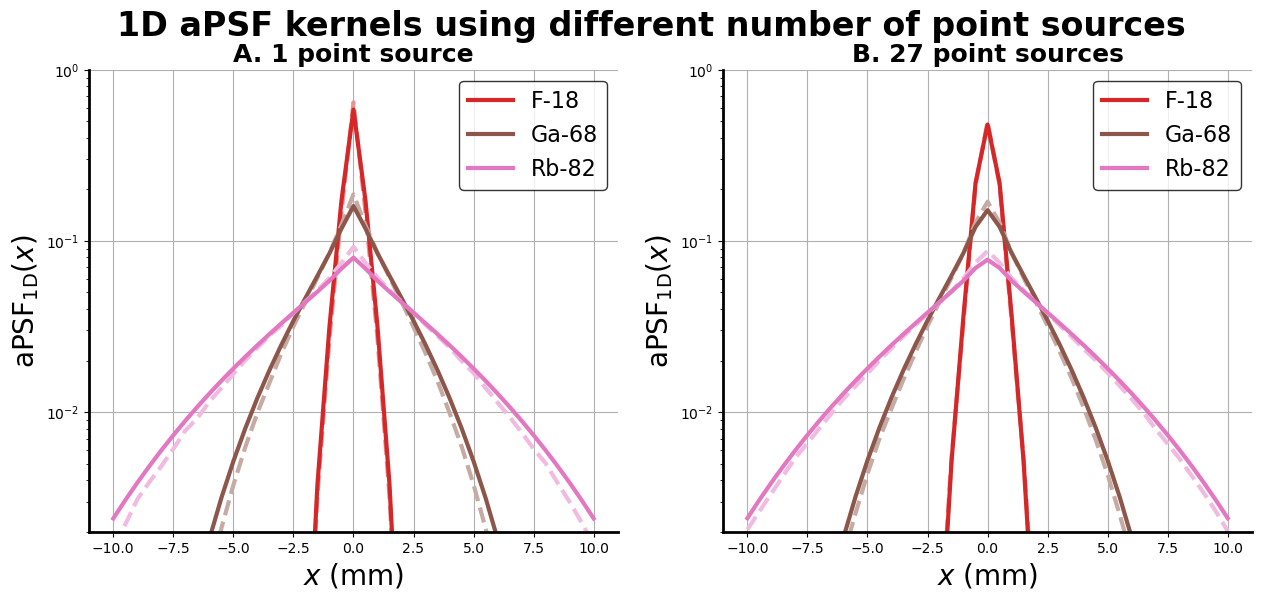

In [32]:
from kernel import VG
from analysis import PRAnalysis

def get_g3D_func(isotope):
    rp, g3D = mg3D[isotope]
    func = lambda r: np.interp(r, rp, g3D)
    return func

def fwhm(x, y):
    half_max = y.max() / 2
    peak_idx = np.argmax(y)

    # find left crossing
    iL = np.where(y[:peak_idx] < half_max)[0][-1]
    iLp = iL + 1
    xL = x[iL] + (half_max - y[iL]) * (x[iLp] - x[iL]) / (y[iLp] - y[iL])

    # find right crossing
    iR = peak_idx + np.where(y[peak_idx:] < half_max)[0][0]
    iRp = iR - 1
    xR = x[iRp] + (half_max - y[iRp]) * (x[iR] - x[iRp]) / (y[iR] - y[iRp])

    fwhm = xR - xL
    return fwhm

code = "PenEasy2024"
material = "Water"
kernel_size = [41]*3
kernel_step = [50e-2/10]*3 # voxel size in cm

nx, ny, nz = kernel_size
cx, cy, cz = (nx-1)/2, (ny-1)/2, (nz-1)/2
x = np.arange(nx)[:,None,None]
y = np.arange(ny)[None,:,None]
z = np.arange(nz)[None,None,:]
D = np.sqrt((x-cx)**2 + (y-cy)**2 + (z-cz)**2)

isotopes = ["F18", "Ga68", "Rb82"]

fig = plt.figure(figsize=(15, 6))
fig.suptitle(f"1D aPSF kernels using different number of point sources", fontsize=24, fontweight='bold')
plt.gca().set_axis_off()
for iso in isotopes:
    input_file_S1 = f"RESULTS/SPC/{material}/{code}_xyz/{iso}.dat" # in cm
    simul_data_S1 = PRAnalysis(f"{iso} S1", input_file_S1, SIZE=kernel_size, STEP=kernel_step) 
    xdata = simul_data_S1.xp*10
    real_aPSFx_S1 = simul_data_S1.aPSFx
    aPSF_kernel_sim_S1 = simul_data_S1.img / simul_data_S1.img.sum()

    input_file_S3 = f"RESULTS/kernel/{material}/{code}_xyz/simulated_{iso}_S3.dat" # in cm
    simul_data_S3 = PRAnalysis(f"{iso} S3", input_file_S3, SIZE=kernel_size, STEP=kernel_step) 
    xdata = simul_data_S3.xp*10
    real_aPSFx_S3 = simul_data_S3.aPSFx
    aPSF_kernel_sim_S3 = simul_data_S3.img / simul_data_S3.img.sum()

    print(f"Isotope: {iso}")
    # print(f"\tMaximum kernel PR in x-axis: {simul_data.Xmax*10:.2f} mm")
    # print(f"\tMaximum simulated PR: {simul_data.rmax*10:.2f} mm")
    # print(f"\t90% yield simulated PR: {simul_data.interpol_G3D(0.9)*10:.2f} mm")
    # print(f"\t99% yield simulated PR: {simul_data.interpol_G3D(0.99)*10:.2f} mm")
    # print(f"\tVoxel step size: {kernel_step[0]*10:.2f} mm")

    # Get modeled aPSF3D
    g3D = get_g3D_func(iso)
    aPSF3D_tmp = lambda _r: g3D(_r)/_r**2
    rmin = 1e-8
    aPSF3D = lambda _r: aPSF3D_tmp(np.where(_r < rmin, rmin, _r))
    aPSF_kernel_VG_S1 = VG(aPSF3D, kernel_step, kernel_size, rlim=(rmin, None), voxel_griding=15, source_griding=1, disable_tqdm=False)
    aPSF_kernel_VG_S3 = VG(aPSF3D, kernel_step, kernel_size, rlim=(rmin, None), voxel_griding=15, source_griding=3, disable_tqdm=False)

    kernel_aPSFx_S1 = np.sum(aPSF_kernel_VG_S1, axis=(1, 2))
    kernel_aPSFx_S1 /= kernel_aPSFx_S1.sum()
    kernel_aPSFx_S3 = np.sum(aPSF_kernel_VG_S3, axis=(1, 2))
    kernel_aPSFx_S3 /= kernel_aPSFx_S3.sum()
    real_aPSFx_S1 /= real_aPSFx_S1.sum()
    real_aPSFx_S3 /= real_aPSFx_S3.sum()
    XX_S1 = simul_data_S1.aPSFx_range*10
    XX_S3 = simul_data_S3.aPSFx_range*10

    rmask = 0.99
    for S, XX, simul_data, kernel_aPSFx, real_aPSFx, aPSF_kernel_VG, aPSF_kernel_sim in zip([1, 3], 
                                                                                            [XX_S1, XX_S3], 
                                                                                            [simul_data_S1, simul_data_S3], 
                                                                                            [kernel_aPSFx_S1, kernel_aPSFx_S3], 
                                                                                            [real_aPSFx_S1, real_aPSFx_S3],
                                                                                            [aPSF_kernel_VG_S1, aPSF_kernel_VG_S3],
                                                                                            [aPSF_kernel_sim_S1, aPSF_kernel_sim_S3]):
        mask = abs(XX) <= simul_data.interpol_G3D(rmask)
        res = kernel_aPSFx - real_aPSFx
        print(f"\tS{S} kernel from x=0 to |x|=r_{rmask*100}%:")

        rmse = np.sqrt(np.sum(res[mask]**2) / len(res[mask]))
        print(f"\t\tRMSE: {rmse:.2f}")

        deviation = np.abs(res[mask] / real_aPSFx[mask]) * 100
        print(f"\t\tMaximum abs deviation: {deviation.max():.2f}%")

        r2 = 1.0 - np.sum(res[mask]**2) / np.sum((real_aPSFx[mask]-np.mean(real_aPSFx[mask]))**2)
        print(f"\t\tR2: {r2:.2f}")

        mean_blur_radius_VG = np.sum(aPSF_kernel_VG * D) / np.sum(aPSF_kernel_VG)
        mean_blur_radius_sim = np.sum(aPSF_kernel_sim * D) / np.sum(aPSF_kernel_sim)
        print(f"\t\tMean blur radius (VG): {mean_blur_radius_VG:.2f} mm")
        print(f"\t\tMean blur radius (sim): {mean_blur_radius_sim:.2f} mm")

        nkernel_aPSFx = kernel_aPSFx / np.max(kernel_aPSFx)
        nreal_aPSFx = real_aPSFx / np.max(real_aPSFx)
        FWHM_VG = fwhm(XX, nkernel_aPSFx)
        FWHM_sim = fwhm(XX, nreal_aPSFx)
        print(f"\t\tFWHM (sim): {FWHM_sim:.2f} mm")
        print(f"\t\tFWHM (VG): {FWHM_VG:.2f} mm ({(FWHM_VG-FWHM_sim)/FWHM_sim*100:.1f}%)")


    # plt.plot(simul_data.aPSFx_range[mask]*10, deviation, label=f"{iso_in_plots(iso)}")
    plt.subplot(121)
    real_aPSFx_S1 /= real_aPSFx_S1.sum()
    kernel_aPSFx_S1 /= kernel_aPSFx_S1.sum()
    plt.plot(XX_S1, real_aPSFx_S1, '--', markersize=10, color=colors[iso]["light"])
    plt.plot(XX_S1, kernel_aPSFx_S1, '-', color=colors[iso]["dark"])
    plt.subplot(122)
    real_aPSFx_S3 /= real_aPSFx_S3.sum()
    kernel_aPSFx_S3 /= kernel_aPSFx_S3.sum()
    plt.plot(XX_S3, real_aPSFx_S3, '--', markersize=10, color=colors[iso]["light"])
    plt.plot(XX_S3, kernel_aPSFx_S3, '-', color=colors[iso]["dark"])

fig_id = ["A", "B"]
for i, S in enumerate([1, 3]):
    plt.subplot(1,2,1+i)
    plt.xlabel(r"$x$ (mm)")
    plt.ylabel(r"$\mathrm{aPSF}_\mathrm{1D}(x)$")
    for iso in isotopes:
        plt.plot([], [] , '-', label=iso_in_plots(iso), color=colors[iso]["dark"])
    # plt.plot([], [] , '-', label="Simulated", color='black')
    # plt.plot([], [] , ':', label="Generated", color='black')
    plt.legend(ncols=2)
    plt.yscale('log')
    plt.ylim(2e-3, 1)
    ax, leg = aesthetic_plot(legend_size=16, linewidth=3)
    ax.set_title(f"{fig_id[i]}. {S**3} point source{'s' if S>1 else ''}", fontsize=18, fontweight='bold')

plt.show()
# plt.subplot(122)
# iso = "Rb82"
# g3D = get_g3D_func(iso)
# aPSF3D_tmp = lambda _r: g3D(_r)/_r**2
# rmin = 1e-8
# aPSF3D = lambda _r: aPSF3D_tmp(np.where(_r < rmin, rmin, _r))

# input_file = f"RESULTS/kernel/{material}/{code}_xyz/simulated_{iso}_S3.dat" # in cm
# simul_data = PRAnalysis(f"{iso} kernel", input_file, SIZE=kernel_size, STEP=kernel_step) 
# aPSF_kernel_sim_S3 = simul_data.img / simul_data.img.sum()

# # aPSF_kernel_VG_S3 = VG(aPSF3D, kernel_step, kernel_size, rlim=(rmin, None), voxel_griding=15, source_griding=5, disable_tqdm=False)
# dev = np.abs(aPSF_kernel_VG_S3 - aPSF_kernel_sim_S3)#*1e3 / (aPSF_kernel_sim_S3*1e3) * 100
# # mask = (aPSF_kernel_sim_S3 < 1e-4)
# # dev[mask] = 0
# maxdev = np.max(dev)
# mindev = np.min(dev)
# dev_flat = dev.flatten()
# unique_devs = np.unique(dev_flat)
# if unique_devs.size > 1:
#     second_min = unique_devs[1]
# else:
#     second_min = unique_devs[0]
# print(f"Second minimum deviation: {second_min:.2f}%, {second_min:.2e}")
# print(f"Maximum deviation: {maxdev:.2f}%, {maxdev:.2e}")
# print(f"Minimum deviation: {mindev:.2f}%, {mindev:.2e}")

# from matplotlib import ticker

# midz = dev.shape[2] // 2
# ñ = midz
# DEV = np.sum(dev[...,midz-ñ:midz+ñ+1], axis=2)
# minDEV = np.min(DEV)
# maxDEV = np.max(DEV)

# print(f"Maximum deviation: {maxDEV:.2f}%, {maxDEV:.2e}")
# print(f"Minimum deviation: {minDEV:.2f}%, {minDEV:.2e}")

# # Define white at 0% deviation
# from matplotlib.colors import TwoSlopeNorm
# # norm = TwoSlopeNorm(vmin=minDEV, vcenter=0.0, vmax=maxDEV)

# # plt.imshow(np.abs(DEV), cmap='binary', interpolation=None)
# # plt.imshow(aPSF_kernel_VG_S3[:,:,midz], cmap='binary', interpolation=None)
# plt.xlabel(r"$x$ (voxel)", fontsize=20)
# plt.ylabel(r"$y$ (voxel)", fontsize=20)
# cbar = plt.colorbar(shrink=0.8)
# # cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}%'))
# cbar.ax.yaxis.set_offset_position('left')
# cbar.formatter.set_powerlimits((0, 0))
# cbar.formatter.set_useMathText(True)
# plt.title(f"B. Differences of our method\nagainst the MC simulation", fontsize=18, fontweight='bold')
# plt.show()